In [1]:
import os
import sys
import scipy.io
import scipy.misc
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from PIL import Image
from nst_utils import *
import numpy as np
import tensorflow as tf

In [2]:
model = load_vgg_model("pretrained-model/imagenet-vgg-verydeep-19.mat")
print(model)


{'input': <tf.Variable 'Variable:0' shape=(1, 300, 400, 3) dtype=float32_ref>, 'conv1_1': <tf.Tensor 'Relu:0' shape=(1, 300, 400, 64) dtype=float32>, 'conv1_2': <tf.Tensor 'Relu_1:0' shape=(1, 300, 400, 64) dtype=float32>, 'avgpool1': <tf.Tensor 'AvgPool:0' shape=(1, 150, 200, 64) dtype=float32>, 'conv2_1': <tf.Tensor 'Relu_2:0' shape=(1, 150, 200, 128) dtype=float32>, 'conv2_2': <tf.Tensor 'Relu_3:0' shape=(1, 150, 200, 128) dtype=float32>, 'avgpool2': <tf.Tensor 'AvgPool_1:0' shape=(1, 75, 100, 128) dtype=float32>, 'conv3_1': <tf.Tensor 'Relu_4:0' shape=(1, 75, 100, 256) dtype=float32>, 'conv3_2': <tf.Tensor 'Relu_5:0' shape=(1, 75, 100, 256) dtype=float32>, 'conv3_3': <tf.Tensor 'Relu_6:0' shape=(1, 75, 100, 256) dtype=float32>, 'conv3_4': <tf.Tensor 'Relu_7:0' shape=(1, 75, 100, 256) dtype=float32>, 'avgpool3': <tf.Tensor 'AvgPool_2:0' shape=(1, 38, 50, 256) dtype=float32>, 'conv4_1': <tf.Tensor 'Relu_8:0' shape=(1, 38, 50, 512) dtype=float32>, 'conv4_2': <tf.Tensor 'Relu_9:0' sha

D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.


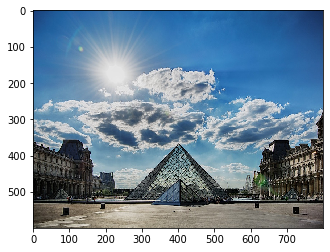

In [3]:
content_image = scipy.misc.imread("images/louvre.jpg")
imshow(content_image)

In [127]:
def compute_content_cost(a_C, a_G):
    """
    Computes the content cost
    
    Arguments:
    a_C -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing content of the image C 
    a_G -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing content of the image G
    
    Returns: 
    J_content -- scalar that you compute using equation 1 above.
    """
    
    ### START CODE HERE ###
    # Retrieve dimensions from a_G (≈1 line)
    m, n_H, n_W, n_C = a_G.get_shape().as_list() #m is the # of img
    
    # Reshape a_C and a_G (≈2 lines)
    a_C_unrolled = tf.transpose(tf.reshape(a_C,(n_H*n_W,n_C)))
    a_G_unrolled = tf.transpose(tf.reshape(a_G,(n_H*n_W,n_C)))

    # compute the cost with tensorflow (≈1 line)

    J_content = tf.reduce_sum(tf.square(tf.subtract(a_C_unrolled,a_G_unrolled)))/(4*n_H*n_W*n_C)
    ### END CODE HERE ###
    
    return J_content


In [128]:
tf.reset_default_graph()

with tf.Session() as test:
    tf.set_random_seed(1)
    a_C = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)
    a_G = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)
    J_content = compute_content_cost(a_C, a_G)
    print("J_content = " + str(J_content.eval()))

J_content = 6.7655935


D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.


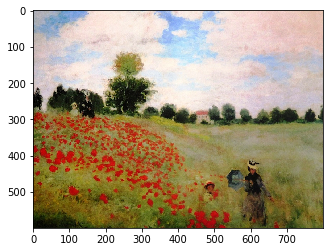

In [61]:
style_image = scipy.misc.imread("images/monet_800600.jpg")
imshow(style_image)


In [68]:
def gram_matrix(A):
    """
    Argument:
    A -- matrix of shape (n_C, n_H*n_W)
    
    Returns:
    GA -- Gram matrix of A, of shape (n_C, n_C)
    """
    
    ### START CODE HERE ### (≈1 line)
    GA = tf.linalg.matmul(A,tf.transpose(A))
    ### END CODE HERE ###
    
    return GA

In [69]:
tf.reset_default_graph()

with tf.Session() as test:
    tf.set_random_seed(1)
    A = tf.random_normal([3, 2*1], mean=1, stddev=4)
    GA = gram_matrix(A)
    
    print("GA = " + str(GA.eval()))

GA = [[ 6.422305 -4.429122 -2.096682]
 [-4.429122 19.465837 19.563871]
 [-2.096682 19.563871 20.686462]]


In [145]:
def compute_layer_style_cost(a_S, a_G):
    """
    Arguments:
    a_S -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing style of the image S 
    a_G -- tensor of dimension (1, n_H, n_W, n_C), hidden layer activations representing style of the image G
    
    Returns: 
    J_style_layer -- tensor representing a scalar value, style cost defined above by equation (2)
    """
    
    ### START CODE HERE ###
    # Retrieve dimensions from a_G (≈1 line)
    m, n_H, n_W, n_C = a_G.get_shape().as_list()
    #sess=tf.Session()
    #print(sess.run(a_G))
    # Reshape the images to have them of shape (n_C, n_H*n_W) (≈2 lines)
    a_S = tf.transpose(tf.reshape(a_S,(n_H*n_W,n_C))) #不能用tf.reshape(a_S,(n_C,n_H*n_W),因為n_H*n_W是column
    a_G = tf.transpose(tf.reshape(a_G,(n_H*n_W,n_C)))

    # Computing gram_matrices for both images S and G (≈2 lines)
    GS = tf.linalg.matmul(a_S,tf.transpose(a_S))
    GG = tf.linalg.matmul(a_G,tf.transpose(a_G))

    # Computing the loss (≈1 line)
    J_style_layer = tf.reduce_sum(tf.square(tf.subtract(GS,GG)))/(4*(n_H*n_W*n_C)*(n_H*n_W*n_C))

    ### END CODE HERE ###
    
    return J_style_layer

In [146]:
tf.reset_default_graph()

with tf.Session() as test:
    tf.set_random_seed(1)
    a_S = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)
    a_G = tf.random_normal([1, 4, 4, 3], mean=1, stddev=4)
    J_style_layer = compute_layer_style_cost(a_S, a_G)
    
    print("J_style_layer = " + str(J_style_layer.eval()))

J_style_layer = 9.190278


In [147]:
STYLE_LAYERS = [
    ('conv1_1', 0.2),
    ('conv2_1', 0.2),
    ('conv3_1', 0.2),
    ('conv4_1', 0.2),
    ('conv5_1', 0.2)]

In [148]:
def compute_style_cost(model, STYLE_LAYERS):
    """
    Computes the overall style cost from several chosen layers
    
    Arguments:
    model -- our tensorflow model
    STYLE_LAYERS -- A python list containing:
                        - the names of the layers we would like to extract style from
                        - a coefficient for each of them
    
    Returns: 
    J_style -- tensor representing a scalar value, style cost defined above by equation (2)
    """
    
    # initialize the overall style cost
    J_style = 0

    for layer_name, coeff in STYLE_LAYERS:

        # Select the output tensor of the currently selected layer
        out = model[layer_name]

        # Set a_S to be the hidden layer activation from the layer we have selected, by running the session on out
        a_S = sess.run(out)

        # Set a_G to be the hidden layer activation from same layer. Here, a_G references model[layer_name] 
        # and isn't evaluated yet. Later in the code, we'll assign the image G as the model input, so that
        # when we run the session, this will be the activations drawn from the appropriate layer, with G as input.
        a_G = out
        
        # Compute style_cost for the current layer
        J_style_layer = compute_layer_style_cost(a_S, a_G)

        # Add coeff * J_style_layer of this layer to overall style cost
        J_style += coeff * J_style_layer

    return J_style

In [149]:
def total_cost(J_content, J_style, alpha = 10, beta = 40):
    """
    Computes the total cost function
    
    Arguments:
    J_content -- content cost coded above
    J_style -- style cost coded above
    alpha -- hyperparameter weighting the importance of the content cost
    beta -- hyperparameter weighting the importance of the style cost
    
    Returns:
    J -- total cost as defined by the formula above.
    """
    
    ### START CODE HERE ### (≈1 line)
    J = alpha*J_content+beta*J_style
    ### END CODE HERE ###
    
    return J

In [150]:

tf.reset_default_graph()

with tf.Session() as test:
    np.random.seed(3)
    J_content = np.random.randn()    
    J_style = np.random.randn()
    J = total_cost(J_content, J_style)
    print("J = " + str(J))

J = 35.34667875478276


In [151]:

# Reset the graph
tf.reset_default_graph()

# Start interactive session
sess = tf.InteractiveSession()

D:\anaconda\envs\tensorflow-gpu\lib\site-packages\tensorflow_core\python\client\session.py:1750: UserWarning: An interactive session is already active. This can cause out-of-memory errors in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s).
  warnings.warn('An interactive session is already active. This can '


In [178]:
content_image = scipy.misc.imread("images/louvre_small.jpg")
content_image = reshape_and_normalize_image(content_image)

D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.


In [179]:
style_image = scipy.misc.imread("images/monet.jpg")
style_image = reshape_and_normalize_image(style_image)
#reshape_and_normalize_image使輸入的影像可以讓VGG判讀

D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.


In [186]:
generated_image = generate_noise_image(content_image)
imshow(generated_image[0])


ValueError: operands could not be broadcast together with shapes (1,300,400,3) (1,225,300,3) 

In [155]:
model = load_vgg_model("pretrained-model/imagenet-vgg-verydeep-19.mat")

In [197]:

# Assign the content image to be the input of the VGG model.  
sess.run(model['input'].assign(content_image))

# Select the output tensor of layer conv4_2
out = model['conv4_2']

# Set a_C to be the hidden layer activation from the layer we have selected
a_C = sess.run(out)

# Set a_G to be the hidden layer activation from same layer. Here, a_G references model['conv4_2'] 
# and isn't evaluated yet. Later in the code, we'll assign the image G as the model input, so that
# when we run the session, this will be the activations drawn from the appropriate layer, with G as input.
a_G = out

# Compute the content cost
J_content = compute_content_cost(a_C, a_G)

In [198]:
sess.run(model['input'].assign(style_image))
J_style = compute_style_cost(model, STYLE_LAYERS)

In [199]:

### START CODE HERE ### (1 line)
J = total_cost(J_content,J_style,alpha=10,beta=40)
### END CODE HERE ###
# define optimizer (1 line)
optimizer = tf.train.AdamOptimizer(2.0)

# define train_step (1 line)
train_step = optimizer.minimize(J)

In [159]:
def model_nn(sess, input_image, num_iterations = 200):
    
    # Initialize global variables (you need to run the session on the initializer)
    ### START CODE HERE ### (1 line)
    sess.run(tf.global_variables_initializer())
    ### END CODE HERE ###
    
    # Run the noisy input image (initial generated image) through the model. Use assign().
    ### START CODE HERE ### (1 line)
    sess.run(model["input"].assign(input_image))
    ### END CODE HERE ###
    
    for i in range(num_iterations):
    
        # Run the session on the train_step to minimize the total cost
        ### START CODE HERE ### (1 line)
        sess.run(train_step)
        ### END CODE HERE ###
        
        # Compute the generated image by running the session on the current model['input']
        ### START CODE HERE ### (1 line)
        generated_image = sess.run(model["input"])
        ### END CODE HERE ###

        # Print every 20 iteration.
        if i%20 == 0:
            Jt, Jc, Js = sess.run([J, J_content, J_style])
            print("Iteration " + str(i) + " :")
            print("total cost = " + str(Jt))
            print("content cost = " + str(Jc))
            print("style cost = " + str(Js))
            
            # save current generated image in the "/output" directory
            save_image("output/" + str(i) + ".png", generated_image)
    
    # save last generated image
    save_image('output/generated_image.jpg', generated_image)
    
    return generated_image

In [160]:
model_nn(sess, generated_image)

Iteration 0 :
total cost = 4934334500.0
content cost = 7861.173
style cost = 123356390.0
Iteration 20 :
total cost = 932594800.0
content cost = 15134.003
style cost = 23311086.0
Iteration 40 :
total cost = 477675260.0
content cost = 16790.393
style cost = 11937684.0
Iteration 60 :
total cost = 306710820.0
content cost = 17383.035
style cost = 7663424.5
Iteration 80 :
total cost = 223919040.0
content cost = 17672.248
style cost = 5593558.0
Iteration 100 :
total cost = 177024960.0
content cost = 17874.51
style cost = 4421155.0
Iteration 120 :
total cost = 146718800.0
content cost = 18025.887
style cost = 3663463.5
Iteration 140 :
total cost = 125144730.0
content cost = 18152.303
style cost = 3124080.2
Iteration 160 :
total cost = 108827690.0
content cost = 18269.145
style cost = 2716125.0
Iteration 180 :
total cost = 95921640.0
content cost = 18389.059
style cost = 2393443.8


array([[[[-4.95392914e+01, -5.84849815e+01,  4.78550835e+01],
         [-2.52572365e+01, -3.83341064e+01,  3.68458023e+01],
         [-4.29229965e+01, -2.78815174e+01,  1.53069496e+01],
         ...,
         [-2.47917862e+01, -1.13619509e+01,  1.42158127e+01],
         [-2.81911373e+01, -5.48145914e+00,  2.28303585e+01],
         [-3.73911552e+01, -4.36982679e+00,  5.10766754e+01]],

        [[-6.34613571e+01, -4.93194122e+01,  3.13231888e+01],
         [-3.24924278e+01, -2.94430332e+01,  1.97115231e+00],
         [-2.82013950e+01, -3.03072739e+01,  1.62809105e+01],
         ...,
         [-2.58915424e+01, -9.19278049e+00,  2.50164680e+01],
         [-1.94169502e+01, -1.91328697e+01,  1.27191944e+01],
         [-3.60753822e+01, -8.07703495e+00,  9.87844181e+00]],

        [[-5.39718208e+01, -4.98305626e+01,  1.57395878e+01],
         [-3.73055496e+01, -4.02097321e+01, -3.69490576e+00],
         [-3.55497932e+01, -2.51734180e+01,  6.99540854e+00],
         ...,
         [-1.36501093e+0

In [170]:
model

{'input': <tf.Variable 'Variable:0' shape=(1, 300, 400, 3) dtype=float32_ref>,
 'conv1_1': <tf.Tensor 'Relu:0' shape=(1, 300, 400, 64) dtype=float32>,
 'conv1_2': <tf.Tensor 'Relu_1:0' shape=(1, 300, 400, 64) dtype=float32>,
 'avgpool1': <tf.Tensor 'AvgPool:0' shape=(1, 150, 200, 64) dtype=float32>,
 'conv2_1': <tf.Tensor 'Relu_2:0' shape=(1, 150, 200, 128) dtype=float32>,
 'conv2_2': <tf.Tensor 'Relu_3:0' shape=(1, 150, 200, 128) dtype=float32>,
 'avgpool2': <tf.Tensor 'AvgPool_1:0' shape=(1, 75, 100, 128) dtype=float32>,
 'conv3_1': <tf.Tensor 'Relu_4:0' shape=(1, 75, 100, 256) dtype=float32>,
 'conv3_2': <tf.Tensor 'Relu_5:0' shape=(1, 75, 100, 256) dtype=float32>,
 'conv3_3': <tf.Tensor 'Relu_6:0' shape=(1, 75, 100, 256) dtype=float32>,
 'conv3_4': <tf.Tensor 'Relu_7:0' shape=(1, 75, 100, 256) dtype=float32>,
 'avgpool3': <tf.Tensor 'AvgPool_2:0' shape=(1, 38, 50, 256) dtype=float32>,
 'conv4_1': <tf.Tensor 'Relu_8:0' shape=(1, 38, 50, 512) dtype=float32>,
 'conv4_2': <tf.Tensor 'R

D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.
D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:3: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  This is separate from the ipykernel package so we can avoid doing imports until
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1, 300, 400, 3)
(1, 300, 400, 3)


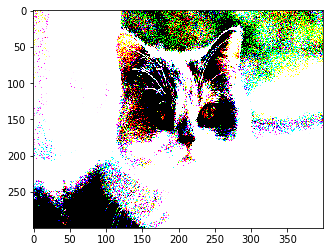

In [191]:
content_image = scipy.misc.imread("images/cat.jpg")
content_image = reshape_and_normalize_image(content_image)
style_image = scipy.misc.imread("images/sandstone.jpg")
style_image = reshape_and_normalize_image(style_image)
print(content_image.shape)
print(style_image.shape)
generated_image = generate_noise_image(content_image)
imshow(generated_image[0])

In [195]:
def model_nn(sess, input_image, num_iterations = 200):
    
    # Initialize global variables (you need to run the session on the initializer)
    ### START CODE HERE ### (1 line)
    sess.run(tf.global_variables_initializer())
    ### END CODE HERE ###
    
    # Run the noisy input image (initial generated image) through the model. Use assign().
    ### START CODE HERE ### (1 line)
    sess.run(model["input"].assign(input_image))
    ### END CODE HERE ###
    
    for i in range(num_iterations):
    
        # Run the session on the train_step to minimize the total cost
        ### START CODE HERE ### (1 line)
        sess.run(train_step)
        ### END CODE HERE ###
        
        # Compute the generated image by running the session on the current model['input']
        ### START CODE HERE ### (1 line)
        generated_image = sess.run(model["input"])
        ### END CODE HERE ###

        # Print every 20 iteration.
        if i%20 == 0:
            Jt, Jc, Js = sess.run([J, J_content, J_style])
            print("Iteration " + str(i) + " :")
            print("total cost = " + str(Jt))
            print("content cost = " + str(Jc))
            print("style cost = " + str(Js))
            
            # save current generated image in the "/output" directory
            save_image("output/" + str(i) + "_cat.png", generated_image)
    
    # save last generated image
    save_image('output/generated_image.jpg', generated_image)
    
    return generated_image
model_nn(sess, generated_image)

Iteration 0 :
total cost = 14061600000.0
content cost = 6316.6416
style cost = 351538400.0
Iteration 20 :
total cost = 4318168000.0
content cost = 16911.799
style cost = 107949980.0
Iteration 40 :
total cost = 1669223800.0
content cost = 19644.326
style cost = 41725684.0
Iteration 60 :
total cost = 683696000.0
content cost = 20473.404
style cost = 17087282.0
Iteration 80 :
total cost = 354137300.0
content cost = 20943.66
style cost = 8848197.0
Iteration 100 :
total cost = 229438770.0
content cost = 21234.342
style cost = 5730661.0
Iteration 120 :
total cost = 168359710.0
content cost = 21458.705
style cost = 4203628.0
Iteration 140 :
total cost = 131860240.0
content cost = 21633.326
style cost = 3291097.5
Iteration 160 :
total cost = 106943860.0
content cost = 21768.674
style cost = 2668154.2
Iteration 180 :
total cost = 88738424.0
content cost = 21890.273
style cost = 2212988.0


array([[[[ 1.67309387e+02,  9.49925613e+01,  3.75767670e+01],
         [ 1.08195023e+02,  1.82045708e+01,  7.57240963e+00],
         [ 9.97685394e+01,  7.71112156e+00, -2.17190075e+01],
         ...,
         [ 7.77391434e+01, -4.47566032e+01, -1.01213036e+02],
         [-1.09338531e+01, -6.41361923e+01, -9.32006073e+01],
         [ 7.84367676e+01, -6.89272738e+00,  2.58654380e+00]],

        [[ 4.07387581e+01, -7.49020004e+01, -1.29928009e+02],
         [ 1.04678085e+02, -3.88907127e+01, -5.12049561e+01],
         [ 6.59150085e+01, -1.08158905e+02, -6.05170212e+01],
         ...,
         [ 4.92659035e+01, -7.71504593e+01, -1.30629440e+02],
         [ 2.86463490e+01, -4.83821793e+01, -9.18740540e+01],
         [ 8.91554260e+01, -2.50186005e+01, -1.57162132e+01]],

        [[ 1.62867622e+01, -3.55033417e+01, -1.08742737e+02],
         [ 2.38095055e+01, -6.33275681e+01, -1.30620590e+02],
         [ 4.54000092e+01,  7.56062418e-02, -1.01590446e+02],
         ...,
         [ 3.82817421e+0

D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.
D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:3: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  This is separate from the ipykernel package so we can avoid doing imports until
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(1, 300, 400, 3)
(1, 300, 400, 3)


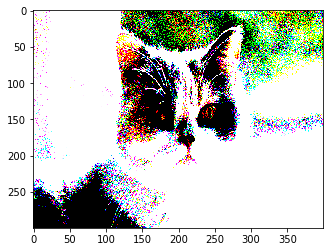

In [196]:
content_image = scipy.misc.imread("images/cat.jpg")
content_image = reshape_and_normalize_image(content_image)
style_image = scipy.misc.imread("images/drop-of-water.jpg")
style_image = reshape_and_normalize_image(style_image)
print(content_image.shape)
print(style_image.shape)
generated_image = generate_noise_image(content_image)
imshow(generated_image[0])

In [201]:
def model_nn(sess, input_image, num_iterations = 200):
    
    # Initialize global variables (you need to run the session on the initializer)
    ### START CODE HERE ### (1 line)
    sess.run(tf.global_variables_initializer())
    ### END CODE HERE ###
    
    # Run the noisy input image (initial generated image) through the model. Use assign().
    ### START CODE HERE ### (1 line)
    sess.run(model["input"].assign(input_image))
    ### END CODE HERE ###
    
    for i in range(num_iterations):
    
        # Run the session on the train_step to minimize the total cost
        ### START CODE HERE ### (1 line)
        sess.run(train_step)
        ### END CODE HERE ###
        
        # Compute the generated image by running the session on the current model['input']
        ### START CODE HERE ### (1 line)
        generated_image = sess.run(model["input"])
        ### END CODE HERE ###

        # Print every 20 iteration.
        if i%20 == 0:
            Jt, Jc, Js = sess.run([J, J_content, J_style])
            print("Iteration " + str(i) + " :")
            print("total cost = " + str(Jt))
            print("content cost = " + str(Jc))
            print("style cost = " + str(Js))
            
            # save current generated image in the "/output" directory
            save_image("output/" + str(i) + "_drop.png", generated_image)
    
    # save last generated image
    save_image('output/generated_image.jpg', generated_image)
    
    return generated_image
model_nn(sess, generated_image)

Iteration 0 :
total cost = 2464021500.0
content cost = 6417.4062
style cost = 61598932.0
Iteration 20 :
total cost = 202048130.0
content cost = 15239.026
style cost = 5047393.5
Iteration 40 :
total cost = 67098464.0
content cost = 16076.7705
style cost = 1673442.4
Iteration 60 :
total cost = 39385600.0
content cost = 16687.426
style cost = 980468.06
Iteration 80 :
total cost = 28944512.0
content cost = 17058.955
style cost = 719348.06
Iteration 100 :
total cost = 23327862.0
content cost = 17281.271
style cost = 578876.25
Iteration 120 :
total cost = 19652360.0
content cost = 17449.875
style cost = 486946.56
Iteration 140 :
total cost = 16996252.0
content cost = 17591.805
style cost = 420508.34
Iteration 160 :
total cost = 14968957.0
content cost = 17711.336
style cost = 369796.1
Iteration 180 :
total cost = 13350498.0
content cost = 17808.88
style cost = 329310.22


array([[[[ -25.572275 ,  -21.474808 ,  -11.469418 ],
         [ -14.716867 ,   -5.7703257,   -6.79861  ],
         [ -33.70508  ,  -15.8953905,  -27.619104 ],
         ...,
         [ -58.920685 ,  -26.558409 ,   56.130573 ],
         [-114.15176  ,  -84.53536  ,  -70.468575 ],
         [-113.13877  , -103.51394  ,  -91.565094 ]],

        [[ -17.75393  ,    5.6616426,   -6.6956983],
         [ -25.613106 ,   -4.5048313,   -6.0804515],
         [  19.910122 ,    6.343312 ,   10.520447 ],
         ...,
         [ -30.382189 ,   35.119225 ,   58.103485 ],
         [ -78.963234 ,  -51.406204 ,  -56.391273 ],
         [ -94.425156 ,  -87.5403   , -103.910736 ]],

        [[ -32.320156 ,   -7.077649 ,   -7.201138 ],
         [ -26.178785 ,    6.233296 ,   11.145722 ],
         [  22.818743 ,   37.045113 ,   23.964575 ],
         ...,
         [  35.73073  ,   79.9093   ,   62.013084 ],
         [   3.719349 ,   71.41197  ,   35.318195 ],
         [ -83.699844 ,  -75.60156  ,  -64.5659   ]],

D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:1: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  """Entry point for launching an IPython kernel.
D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:4: DeprecationWarning: `imread` is deprecated!
`imread` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``imageio.imread`` instead.
  after removing the cwd from sys.path.
D:\anaconda\envs\tensorflow-gpu\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: `imresize` is deprecated!
`imresize` is deprecated in SciPy 1.0.0, and will be removed in 1.2.0.
Use ``skimage.transform.resize`` instead.
  """
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(300, 400, 3)
(1, 300, 400, 3)
Iteration 0 :
total cost = 2432364800.0
content cost = 6496.744
style cost = 60807496.0
Iteration 20 :
total cost = 214954240.0
content cost = 14281.089
style cost = 5370285.5
Iteration 40 :
total cost = 57939744.0
content cost = 15129.45
style cost = 1444711.2
Iteration 60 :
total cost = 28063086.0
content cost = 15568.717
style cost = 697684.94
Iteration 80 :
total cost = 19140350.0
content cost = 15799.509
style cost = 474558.84
Iteration 100 :
total cost = 14984599.0
content cost = 15954.424
style cost = 370626.38
Iteration 120 :
total cost = 12407233.0
content cost = 16074.844
style cost = 306162.12
Iteration 140 :
total cost = 10573675.0
content cost = 16181.2295
style cost = 260296.58
Iteration 160 :
total cost = 9184119.0
content cost = 16275.344
style cost = 225534.16
Iteration 180 :
total cost = 8086376.5
content cost = 16353.654
style cost = 198071.0


array([[[[  1.2162819,  46.25793  , -15.820533 ],
         [-11.345773 ,  34.080517 , -25.576462 ],
         [-16.109217 , -12.091768 , -26.543705 ],
         ...,
         [-65.553055 ,   7.401877 , -23.385256 ],
         [-44.991123 , -15.71679  , -10.514444 ],
         [-73.7183   , -34.18763  , -24.8089   ]],

        [[ 13.776684 ,  62.50987  , -45.305023 ],
         [ 20.309153 ,  44.584335 ,  -5.236545 ],
         [ -3.4373791,  40.616104 ,  -6.697418 ],
         ...,
         [-16.775286 ,  67.93925  ,  41.03685  ],
         [-20.981075 ,  72.17675  ,  18.620956 ],
         [-63.614243 , -26.266582 , -32.964565 ]],

        [[ 16.754345 ,  50.872055 , -40.809963 ],
         [ 38.41703  ,  38.607597 ,   3.449529 ],
         [ 32.21597  ,  34.526543 , -13.67227  ],
         ...,
         [ 56.972916 ,  54.415977 ,  57.31107  ],
         [ 33.505325 ,  47.632614 ,  66.47201  ],
         [-65.90541  ,  58.484352 ,  54.689423 ]],

        ...,

        [[ -7.0619717,  43.017456 ,  1

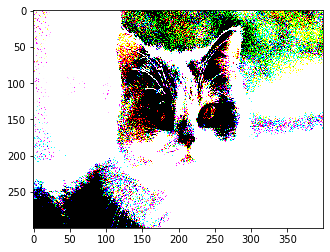

In [212]:
content_image = scipy.misc.imread("images/cat.jpg")
print(content_image.shape)
content_image = reshape_and_normalize_image(content_image)
style_image = scipy.misc.imread("images/stone_style.jpg")
style_image =scipy.misc.imresize(style_image,(300,400,3))
style_image = reshape_and_normalize_image(style_image)
generated_image = generate_noise_image(content_image)
imshow(generated_image[0])
print(style_image.shape)
# Assign the content image to be the input of the VGG model.  
sess.run(model['input'].assign(content_image))

# Select the output tensor of layer conv4_2
out = model['conv4_2']

# Set a_C to be the hidden layer activation from the layer we have selected
a_C = sess.run(out)

# Set a_G to be the hidden layer activation from same layer. Here, a_G references model['conv4_2'] 
# and isn't evaluated yet. Later in the code, we'll assign the image G as the model input, so that
# when we run the session, this will be the activations drawn from the appropriate layer, with G as input.
a_G = out

# Compute the content cost
J_content = compute_content_cost(a_C, a_G)
sess.run(model['input'].assign(style_image))
J_style = compute_style_cost(model, STYLE_LAYERS)
### START CODE HERE ### (1 line)
J = total_cost(J_content,J_style,alpha=10,beta=40)
### END CODE HERE ###
# define optimizer (1 line)
optimizer = tf.train.AdamOptimizer(2.0)

# define train_step (1 line)
train_step = optimizer.minimize(J)
def model_nn(sess, input_image, num_iterations = 200):
    
    # Initialize global variables (you need to run the session on the initializer)
    ### START CODE HERE ### (1 line)
    sess.run(tf.global_variables_initializer())
    ### END CODE HERE ###
    
    # Run the noisy input image (initial generated image) through the model. Use assign().
    ### START CODE HERE ### (1 line)
    sess.run(model["input"].assign(input_image))
    ### END CODE HERE ###
    
    for i in range(num_iterations):
    
        # Run the session on the train_step to minimize the total cost
        ### START CODE HERE ### (1 line)
        sess.run(train_step)
        ### END CODE HERE ###
        
        # Compute the generated image by running the session on the current model['input']
        ### START CODE HERE ### (1 line)
        generated_image = sess.run(model["input"])
        ### END CODE HERE ###

        # Print every 20 iteration.
        if i%20 == 0:
            Jt, Jc, Js = sess.run([J, J_content, J_style])
            print("Iteration " + str(i) + " :")
            print("total cost = " + str(Jt))
            print("content cost = " + str(Jc))
            print("style cost = " + str(Js))
            
            # save current generated image in the "/output" directory
            save_image("output/" + str(i) + "_stone.png", generated_image)
    
    # save last generated image
    save_image('output/generated_image.jpg', generated_image)
    
    return generated_image
model_nn(sess, generated_image)